# Loan Approval Prediction — EDA & Feature Selection

In [2]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.feature_selection import get_correlation_with_target, find_highly_correlated_pairs, select_features
from src.utils import print_section

In [3]:
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [4]:
df = pd.read_csv("../data/loan_approval_cleaned.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (4269, 16)


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_assets_value,loan_to_income_ratio,asset_to_loan_ratio,cibil_band
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,50700000,3.114583,1.695652,Good
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,17000000,2.975610,1.393443,Poor
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,57700000,3.263736,1.942761,Poor
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,52700000,3.743902,1.716612,Poor
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,55000000,2.469388,2.272727,Poor


The cleaned dataset is loaded successfully.
It contains encoded categorical variables,
engineered features,
and scaled numerical values.

## 1. Univariate Analysis

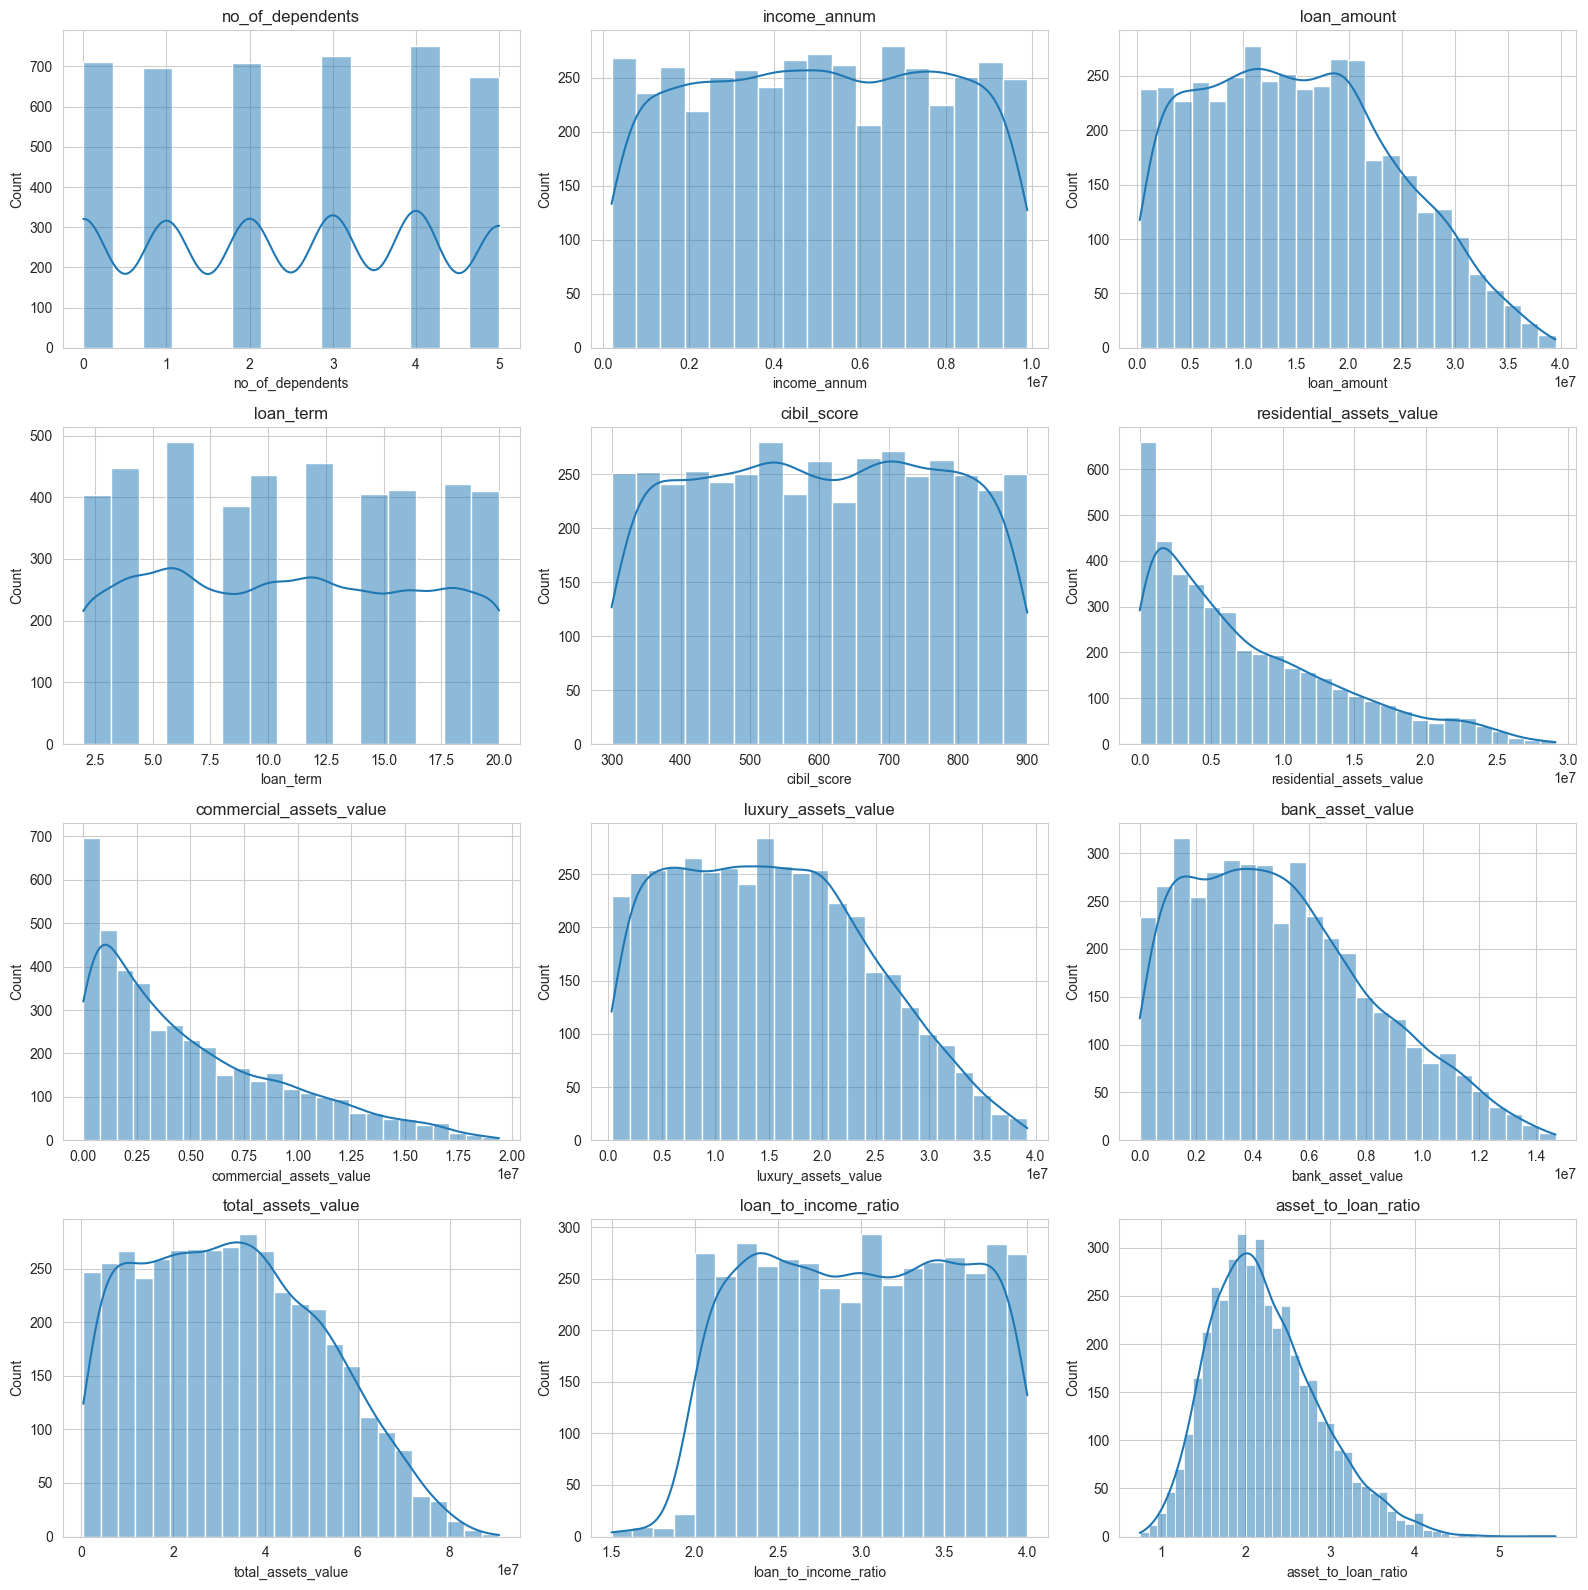

In [5]:
numeric_cols = df.select_dtypes(include="number").drop(columns=["education", "self_employed", "loan_status"], errors="ignore").columns

fig, axes = plt.subplots(nrows=(len(numeric_cols)+2)//3, ncols=3, figsize=(16, 4*((len(numeric_cols)+2)//3)))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("../images/day3_univariate_histograms.png", dpi=100)
plt.show()


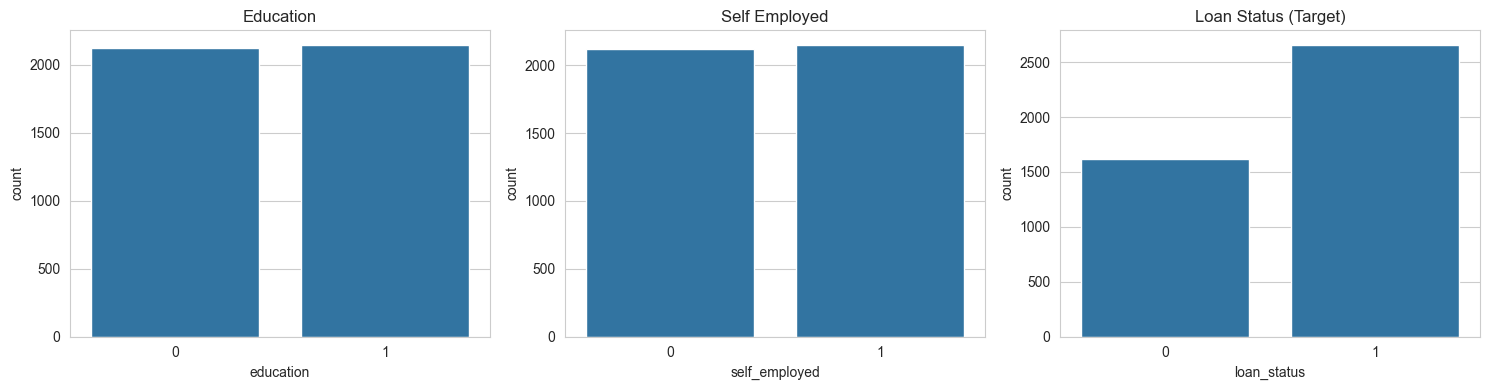

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x="education", data=df, ax=axes[0])
axes[0].set_title("Education")
sns.countplot(x="self_employed", data=df, ax=axes[1])
axes[1].set_title("Self Employed")
sns.countplot(x="loan_status", data=df, ax=axes[2])
axes[2].set_title("Loan Status (Target)")
plt.tight_layout()
plt.savefig("../images/day3_univariate_categorical.png", dpi=100)
plt.show()


**Univariate observations:**

- Most financial variables are right-skewed (skew 0.3-0.98). Features such as income_annum, loan_amount, residential_assets_value, commercial_assets_value, luxury_assets_value, bank_asset_value, and total_assets_value contain a small number of very high values, which creates a longer right tail in their distributions. This pattern is common in income and asset-related data.

- CIBIL scores are distributed across a wide range of values. The distribution is fairly even, with only a very slight left skew (skew ≈ -0.01), indicating that applicants are not concentrated within a single credit score range.

- The categorical features are reasonably balanced. Both education and self_employed contain proportions that are close to a 50:50 split, which helps reduce bias caused by highly uneven category distributions.

- The target variable is moderately imbalanced. Approximately 62.2% of applications are Approved and 37.8% are Rejected. This imbalance should be considered during preprocessing and model evaluation to ensure reliable predictive performance.

## 2. Bivariate Analysis — Features vs. Target

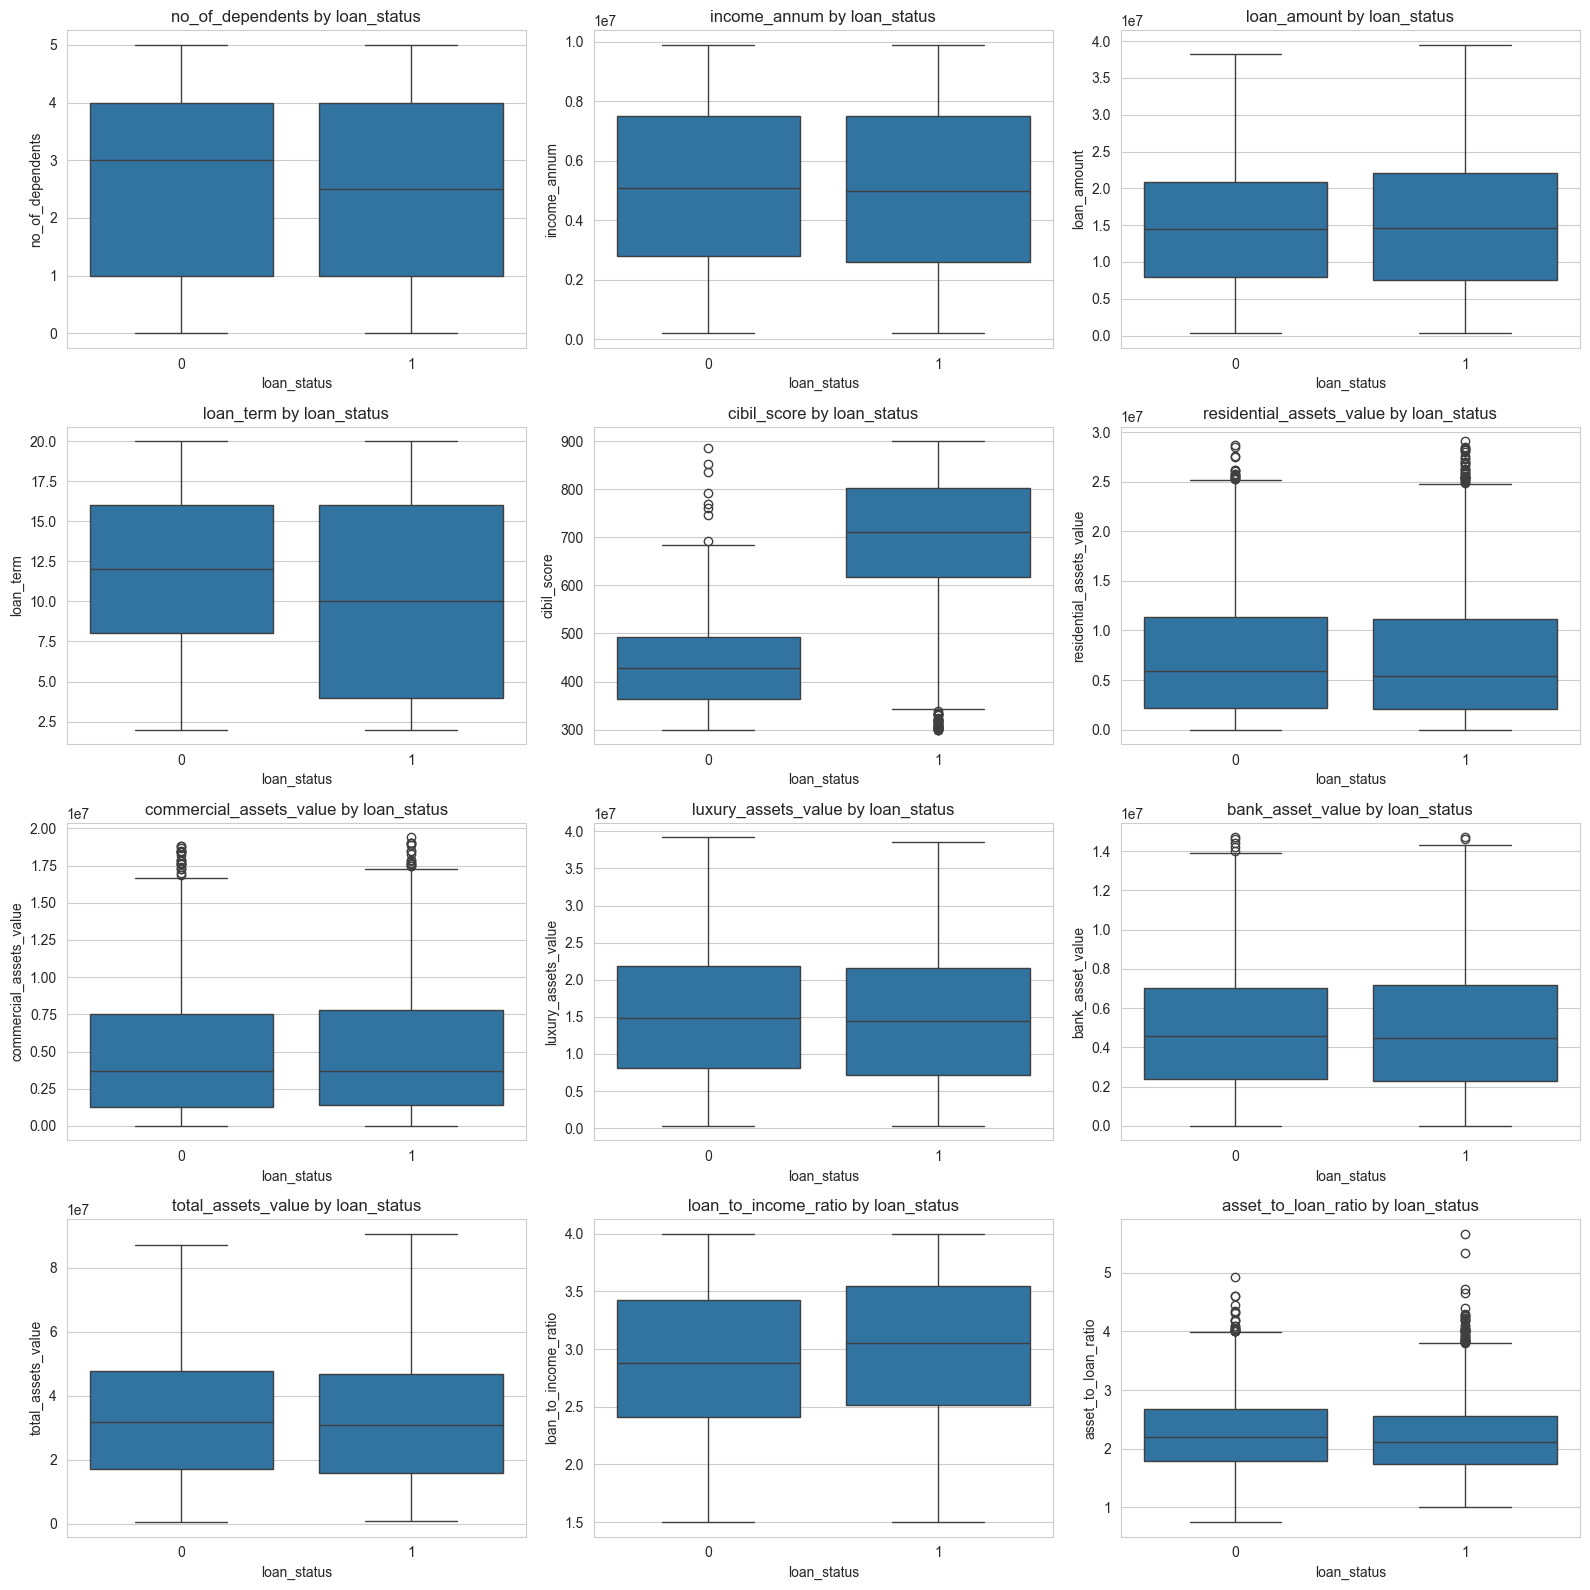

In [7]:
fig, axes = plt.subplots(nrows=(len(numeric_cols)+2)//3, ncols=3, figsize=(16, 4*((len(numeric_cols)+2)//3)))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x="loan_status", y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} by loan_status")
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("../images/day3_bivariate_boxplots.png", dpi=100)
plt.show()


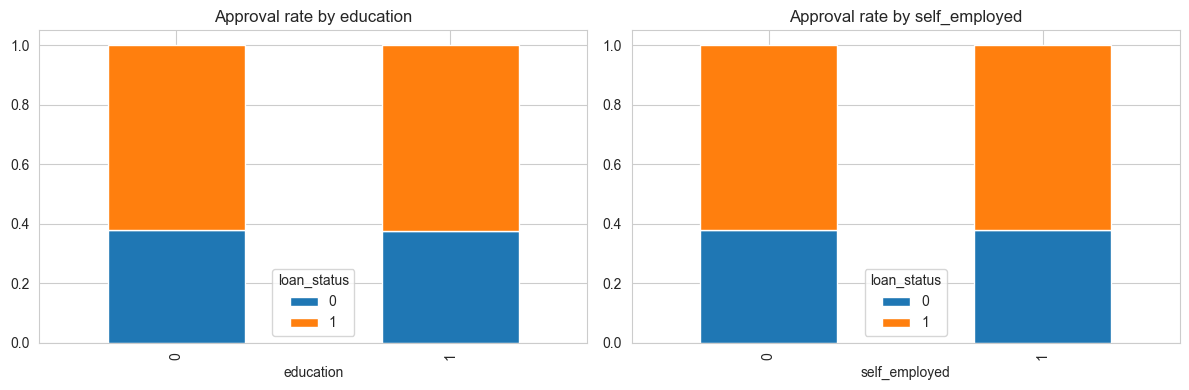

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.crosstab(df["education"], df["loan_status"], normalize="index").plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_title("Approval rate by education")
pd.crosstab(df["self_employed"], df["loan_status"], normalize="index").plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("Approval rate by self_employed")
plt.tight_layout()
plt.savefig("../images/day3_bivariate_categorical.png", dpi=100)
plt.show()


**Bivariate observations:**

- CIBIL score is the strongest indicator of loan approval. Applicants with approved loans have an average CIBIL score of 703, while rejected applicants have an average score of 429. This large difference suggests that credit score has a significant influence on the approval decision.

- Education level has very little impact on loan approval. The approval rate is 62.0% for Graduates and 62.5% for Non-Graduates, indicating that both groups are approved at almost the same rate.

- Self-employment status does not show a meaningful relationship with loan approval. Approval rates are 62.2% for self-employed applicants and 62.0% for non-self-employed applicants, which is nearly identical to the overall approval rate.

- Loan term and financial ratios show only a weak relationship with the target variable. Features such as loan_term, loan_to_income_ratio, and asset_to_loan_ratio display some variation between approved and rejected applicants, but the separation is relatively small compared to the CIBIL score.

## 3. Multivariate Analysis

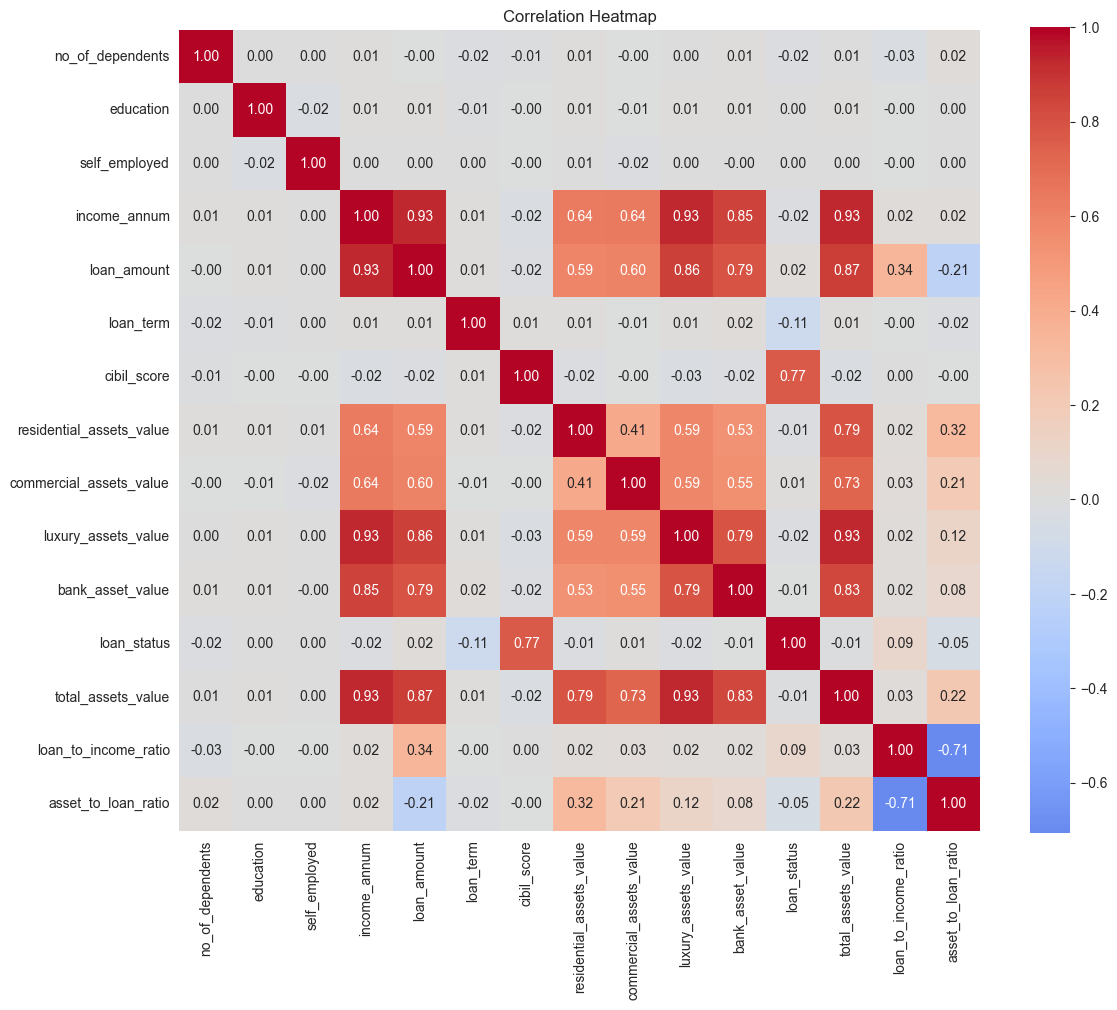

In [9]:
plt.figure(figsize=(12, 10))
corr_matrix = df.select_dtypes(include="number").corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../images/day3_correlation_heatmap.png", dpi=100)
plt.show()


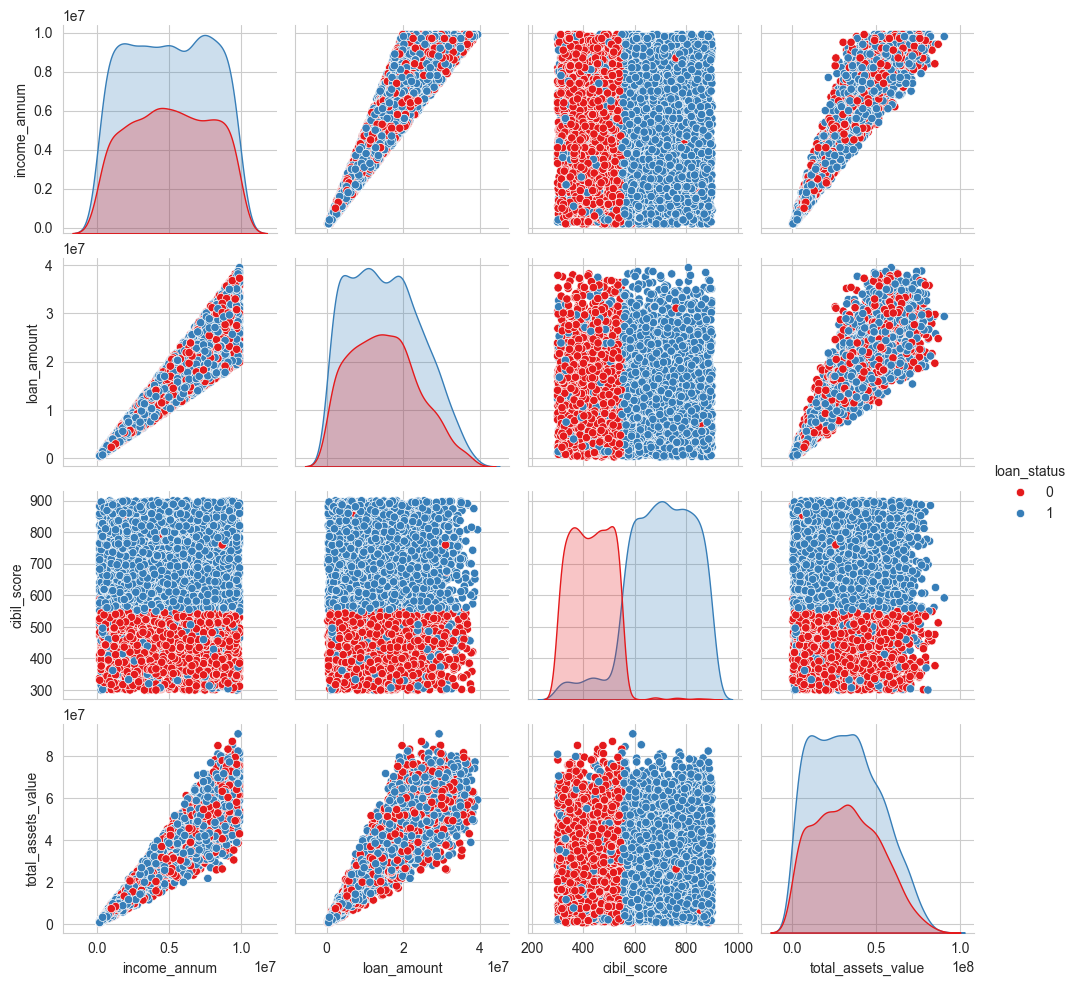

In [10]:
key_features = ["income_annum", "loan_amount", "cibil_score", "total_assets_value", "loan_status"]
key_features = [c for c in key_features if c in df.columns]
sns.pairplot(df[key_features], hue="loan_status", diag_kind="kde", palette="Set1")
plt.savefig("../images/day3_pairplot.png", dpi=100)
plt.show()


**Multivariate Analysis – Key Observations** 
- A strong positive correlation exists among the financial-related features such as `income_annum`, `loan_amount`, `total_assets_value`, and `luxury_assets_value`. This indicates that applicants with higher incomes generally own more assets and tend to apply for larger loan amounts.

- Since these financial features are highly correlated, they provide similar information about an applicant's overall financial capacity. This relationship is known as **multicollinearity**, where multiple variables measure nearly the same underlying characteristic.

- The pairplot shows that the financial-related features have considerable overlap between approved and rejected loan applications, making them less effective at clearly distinguishing the two classes on their own.

- In contrast, `cibil_score` provides a much clearer separation between approved and rejected applicants. Applicants with higher CIBIL scores are more likely to receive loan approval, highlighting it as one of the most important features in the dataset.

- The multivariate analysis suggests that while financial characteristics are useful, they should be interpreted carefully because of their strong interdependence. Techniques such as feature selection or regularization may be beneficial during model development to reduce the impact of multicollinearity.

- Overall, the analysis indicates that **CIBIL score is the strongest individual predictor of loan approval**, whereas the remaining financial variables collectively represent an applicant's financial strength rather than providing unique predictive information.

## 4. Correlation with Target

In [11]:
target_corr = get_correlation_with_target(df, target="loan_status")
target_corr


cibil_score                 0.770518
loan_term                  -0.113036
loan_to_income_ratio        0.087726
asset_to_loan_ratio        -0.050422
no_of_dependents           -0.018114
loan_amount                 0.016150
luxury_assets_value        -0.015465
income_annum               -0.015189
residential_assets_value   -0.014379
total_assets_value         -0.011285
commercial_assets_value     0.008246
bank_asset_value           -0.006778
education                   0.004918
self_employed               0.000345
Name: loan_status, dtype: float64

## 5. Highly Correlated Feature Pairs (multicollinearity check)

In [12]:
pairs = find_highly_correlated_pairs(df, threshold=0.85)
print_section("Feature pairs with |correlation| > 0.85")
for a, b, corr in pairs:
    print(f"{a}  <->  {b}   corr = {corr}")
if not pairs:
    print("No feature pairs exceeded the 0.85 threshold.")



Feature pairs with |correlation| > 0.85
income_annum  <->  total_assets_value   corr = 0.932
income_annum  <->  luxury_assets_value   corr = 0.929
luxury_assets_value  <->  total_assets_value   corr = 0.928
income_annum  <->  loan_amount   corr = 0.927
loan_amount  <->  total_assets_value   corr = 0.867
loan_amount  <->  luxury_assets_value   corr = 0.861
income_annum  <->  bank_asset_value   corr = 0.851


**Correlation observations**

- The correlation analysis reveals strong relationships among financial features such as `income_annum`, `loan_amount`, `total_assets_value`, and `luxury_assets_value`. This indicates that these variables capture similar information about an applicant's financial status.

- Because these features are highly correlated, they introduce **multicollinearity**, meaning that multiple variables provide overlapping information instead of contributing unique insights.

- While multicollinearity has little impact on tree-based models such as Random Forest and XGBoost, it can reduce the performance and interpretability of models such as Logistic Regression, K-Nearest Neighbors (KNN), and Support Vector Machines (SVM).

- To ensure fair model comparison and improve model stability, it is beneficial to address redundant features during the preprocessing stage rather than handling them separately for each algorithm.

- Reducing highly correlated features can simplify the dataset, improve model interpretability, and help prevent unstable predictions in algorithms that are sensitive to multicollinearity.

- Overall, the correlation analysis suggests that selecting the most informative financial features before model training will lead to a more efficient and reliable loan approval prediction model.

## 6. Final Feature Selection Decision

In [13]:
# Decision, based on the correlation analysis above:
#
# 1. Drop the four raw asset columns (residential/commercial/luxury/bank) —
#    they're redundant with total_assets_value by construction (correlations
#    0.73-0.93 with it), and total_assets_value is a cleaner single signal.
#
# 2. Drop cibil_band — it's a deterministic bucketing of cibil_score, which
#    is already kept as a numeric feature. Keeping both is redundant; the
#    raw score preserves more information for every model type tested.
#
# 3. Keep education and self_employed despite their ~0 correlation with the
#    target. They cost nothing computationally, and a near-zero correlation
#    is itself a legitimate finding worth showing in the certification
#    write-up (not every feature needs to be predictive to justify testing it).
#
# 4. Keep total_assets_value alongside income_annum and loan_amount even
#    though they're mutually correlated (0.93) -- flagged for Day 4: use
#    regularization (L2) for Logistic Regression, and prefer tree-based
#    models where multicollinearity matters less.

columns_to_drop = [
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value",
    "cibil_band",
]

df_selected = select_features(df, drop_columns=columns_to_drop, target="loan_status")
print(f"Shape before selection: {df.shape}")
print(f"Shape after selection: {df_selected.shape}")
print(f"Final features: {list(df_selected.columns)}")

Shape before selection: (4269, 16)
Shape after selection: (4269, 11)
Final features: ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'loan_status', 'total_assets_value', 'loan_to_income_ratio', 'asset_to_loan_ratio']


## 7. Save the feature-selected dataset

In [14]:
OUTPUT_PATH = "../data/loan_approval_selected.csv"
df_selected.to_csv(OUTPUT_PATH, index=False)
print(f"Saved: {OUTPUT_PATH}")


Saved: ../data/loan_approval_selected.csv


## 8. Summary

- **CIBIL score** was identified as the most influential feature for predicting loan approval. Applicants with higher CIBIL scores were significantly more likely to have their loans approved than those with lower scores.

- **Education** and **self_employed** showed minimal impact on loan approval, as both categories had nearly identical approval rates. These features are retained for further model evaluation.

- Correlation analysis revealed **multicollinearity** among financial features such as `income_annum`, `loan_amount`, `total_assets_value`, `luxury_assets_value`, and `bank_asset_value`. These variables capture similar information about an applicant's overall financial capacity.

- To reduce redundancy while preserving important information, the individual asset columns (`residential_assets_value`, `commercial_assets_value`, `luxury_assets_value`, and `bank_asset_value`) were removed, while `total_assets_value` was retained as a representative feature. The engineered feature `cibil_band` was also removed because it duplicated the information already contained in `cibil_score`. 
Final feature set: 10 columns + target (down from 15 + target).

- Although some correlation remains among the financial features (`income_annum`/`loan_amount`/`total_assets_value`), it is expected and will be considered during model development. Regularization techniques and algorithms that are less sensitive to correlated features can help reduce its impact.

- The processed dataset is now ready for the next stage of the project, which includes train/test split (stratified on `loan_status`, given the 62/38 imbalance), fit scaler on the training split only, train and compare Logistic Regression, Decision Tree, Random Forest, KNN, Naive Bayes, SVM, and XGBoost using F1 and ROC-AUC as primary metrics.